In [ ]:
# ==========================================
# STEP 1 : Import Required Libraries
# ==========================================

# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Train-test split
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
# ==========================================
# STEP 2 : Load Dataset
# ==========================================

df = pd.read_csv("/content/Employee_Salary_Dataset.csv")

# Display first five rows
df.head()

,ID,Experience_Years,Age,Gender,Salary
0,1,5,28,Female,250000
1,2,1,21,Male,50000
2,3,3,23,Female,170000
3,4,2,22,Male,25000
4,5,1,17,Male,10000


In [ ]:
# ==========================================
# STEP 3 : Explore Dataset
# ==========================================

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Description:")
print(df.describe())

Shape of Dataset:
(35, 5)

Column Names:
Index(['ID', 'Experience_Years', 'Age', 'Gender', 'Salary'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ID                35 non-null     int64 
 1   Experience_Years  35 non-null     int64 
 2   Age               35 non-null     int64 
 3   Gender            35 non-null     object
 4   Salary            35 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1.5+ KB

Statistical Description:
              ID  Experience_Years        Age        Salary
count  35.000000          35.00000  35.000000  3.500000e+01
mean   18.000000           9.20000  35.485714  2.059147e+06
std    10.246951           7.55295  14.643552  3.170124e+06
min     1.000000           1.00000  17.000000  3.000000e+03
25%     9.500000           2.50000  22.500000  2.250000e+04


In [ ]:
# ==========================================
# STEP 4 : Check Missing Values
# ==========================================

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
ID                  0
Experience_Years    0
Age                 0
Gender              0
Salary              0
dtype: int64


In [ ]:
df = df.dropna()

print("Missing values removed.")

Missing values removed.


In [ ]:
# ==========================================
# STEP 5 : Check Duplicate Values
# ==========================================

print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [ ]:
df = df.drop_duplicates()

In [ ]:
# ==========================================
# STEP 6 : Select Input and Target
# ==========================================

# Input feature
X = df[["Experience_Years"]]

# Target variable
y = df[["Salary"]]

print("Input X:")
print(X.head())

print("\nTarget y:")
print(y.head())

Input X:
   Experience_Years
0                 5
1                 1
2                 3
3                 2
4                 1

Target y:
   Salary
0  250000
1   50000
2  170000
3   25000
4   10000


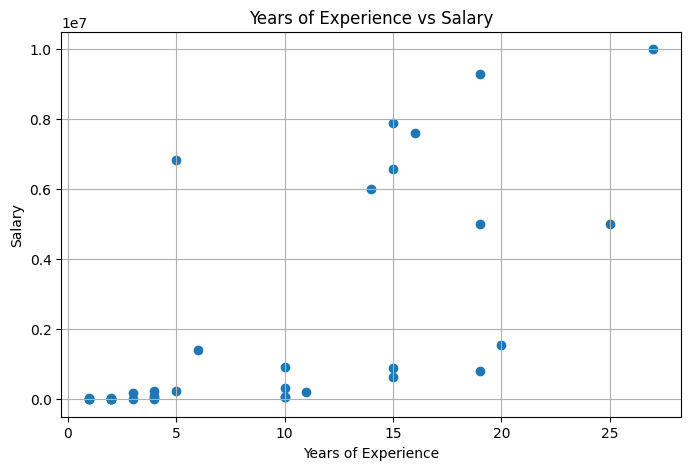

In [ ]:
# ==========================================
# STEP 7 : Visualize Original Dataset
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Experience_Years"],
    df["Salary"]
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# STEP 8 : Split Dataset into Train and Test
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

Training Data Shape:
(28, 1)

Testing Data Shape:
(7, 1)


In [ ]:
# ==========================================
# STEP 9 : Convert Data into PyTorch Tensors
# ==========================================

X_train = torch.tensor(
    X_train.values,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test.values,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test.values,
    dtype=torch.float32
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: torch.Size([28, 1])
X_test Shape : torch.Size([7, 1])
y_train Shape: torch.Size([28, 1])
y_test Shape : torch.Size([7, 1])


In [ ]:
# ==========================================
# STEP 10 : Build Linear Regression Model
# ==========================================

class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        # One input feature and one output
        self.linear = nn.Linear(1, 1)

    def forward(self, x):

        return self.linear(x)


# Create model object
model = LinearRegressionModel()

print(model)

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [ ]:
# ==========================================
# STEP 11 : Display Initial Parameters
# ==========================================

print("Initial Weight:")
print(model.linear.weight)

print("\nInitial Bias:")
print(model.linear.bias)

Initial Weight:
Parameter containing:
tensor([[-0.8252]], requires_grad=True)

Initial Bias:
Parameter containing:
tensor([-0.4386], requires_grad=True)


In [ ]:
# ==========================================
# STEP 12 : Define Loss Function
# ==========================================

criterion = nn.MSELoss()

print("Loss Function:")
print(criterion)

Loss Function:
MSELoss()


In [ ]:
# ==========================================
# STEP 13 : Define Adam Optimizer
# ==========================================

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

print("Optimizer:")
print(optimizer)

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [ ]:
# ==========================================
# STEP 14 : Train the Model
# ==========================================

epochs = 1000

loss_history = []

for epoch in range(epochs):

    # Forward Pass
    predictions = model(X_train)

    # Calculate Loss
    loss = criterion(predictions, y_train)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backward Pass
    loss.backward()

    # Update model parameters
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    # Display loss
    if (epoch + 1) % 100 == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [100/1000], Loss: 17497361219584.0000
Epoch [200/1000], Loss: 17497269993472.0000
Epoch [300/1000], Loss: 17497178767360.0000
Epoch [400/1000], Loss: 17497086492672.0000
Epoch [500/1000], Loss: 17496994217984.0000
Epoch [600/1000], Loss: 17496901943296.0000
Epoch [700/1000], Loss: 17496810717184.0000
Epoch [800/1000], Loss: 17496718442496.0000
Epoch [900/1000], Loss: 17496628264960.0000
Epoch [1000/1000], Loss: 17496533893120.0000


In [ ]:
# ==========================================
# STEP 15 : Display Learned Parameters
# ==========================================

print("Learned Weight:")
print(model.linear.weight.item())

print("\nLearned Bias:")
print(model.linear.bias.item())

Learned Weight:
9.174698829650879

Learned Bias:
9.561307907104492


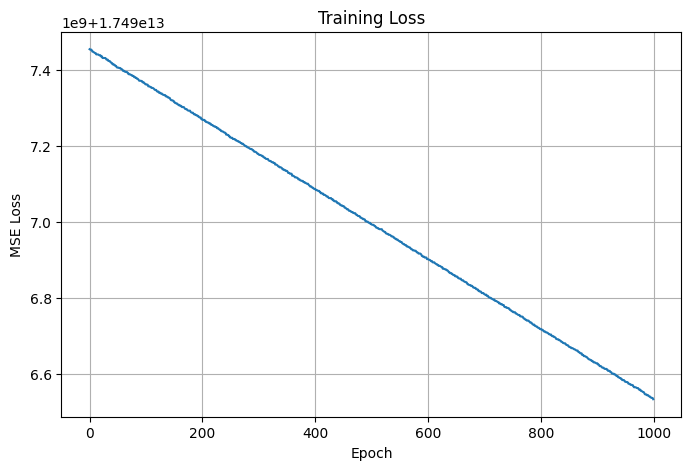

In [ ]:
# ==========================================
# STEP 16 : Plot Training Loss
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# STEP 17 : Make Predictions
# ==========================================

model.eval()

with torch.no_grad():

    y_pred = model(X_test)

print("First 10 Predicted Salaries:")
print(y_pred[:10])

First 10 Predicted Salaries:
tensor([[ 18.7360],
        [110.4830],
        [ 46.2601],
        [ 46.2601],
        [ 46.2601],
        [ 27.9107],
        [101.3083]])


In [ ]:
# ==========================================
# STEP 18 : Compare Actual and Predicted
# ==========================================

print("Actual Salary       Predicted Salary")

for actual, predicted in zip(y_test[:10], y_pred[:10]):

    print(
        f"{actual.item():.2f}"
        f"              "
        f"{predicted.item():.2f}"
    )

Actual Salary       Predicted Salary
3000.00              18.74
220100.00              110.48
8900.00              46.26
25000.00              46.26
87000.00              46.26
6100.00              27.91
330000.00              101.31


In [ ]:
# ==========================================
# STEP 19 : Evaluate the Model
# ==========================================

# Convert tensors to NumPy arrays
y_test_numpy = y_test.numpy()
y_pred_numpy = y_pred.numpy()

# Mean Squared Error
mse = mean_squared_error(
    y_test_numpy,
    y_pred_numpy
)

# Mean Absolute Error
mae = mean_absolute_error(
    y_test_numpy,
    y_pred_numpy
)

# R2 Score
r2 = r2_score(
    y_test_numpy,
    y_pred_numpy
)

print("Model Evaluation")
print("----------------------------")

print("Mean Squared Error :", mse)
print("Mean Absolute Error:", mae)
print("R2 Score           :", r2)

Model Evaluation
----------------------------
Mean Squared Error : 23648047104.0
Mean Absolute Error: 97100.390625
R2 Score           : -0.6622308492660522


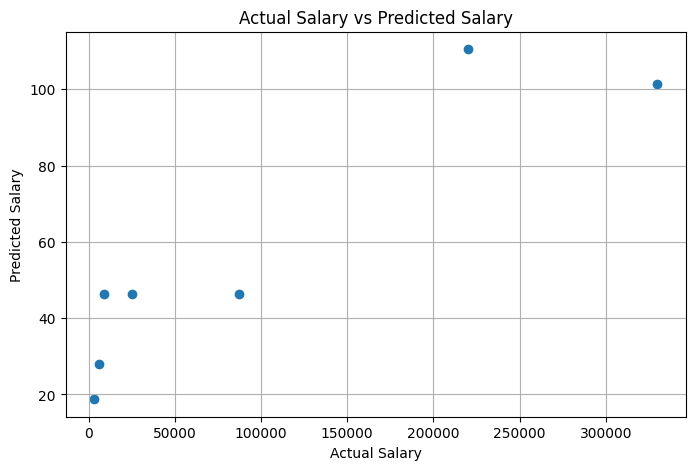

In [ ]:
# ==========================================
# STEP 20 : Actual vs Predicted Salary
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_numpy,
    y_pred_numpy
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title("Actual Salary vs Predicted Salary")

plt.grid(True)

plt.show()

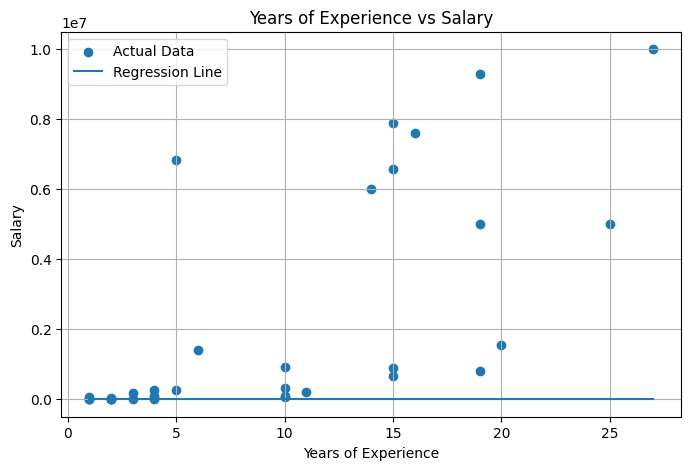

In [ ]:
# ==========================================
# STEP 21 : Plot Regression Line
# ==========================================

plt.figure(figsize=(8, 5))

# Plot original data
plt.scatter(
    df["Experience_Years"],
    df["Salary"],
    label="Actual Data"
)

# Get learned weight and bias
weight = model.linear.weight.item()
bias = model.linear.bias.item()

# Generate values for regression line
x_line = np.linspace(
    df["Experience_Years"].min(),
    df["Experience_Years"].max(),
    100
)

# Calculate predicted salary
y_line = weight * x_line + bias

# Plot regression line
plt.plot(
    x_line,
    y_line,
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.title("Years of Experience vs Salary")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# STEP 22 : Predict Salary for New Employee
# ==========================================

# New employee with 10 years of experience
new_experience = torch.tensor(
    [[10.0]],
    dtype=torch.float32
)

model.eval()

with torch.no_grad():

    predicted_salary = model(new_experience)

print(
    "Predicted Salary for 10 Years of Experience:",
    predicted_salary.item()
)

Predicted Salary for 10 Years of Experience: 101.30829620361328


In [ ]:
# ==========================================
# STEP 23 : Conclusion
# ==========================================

print("""
CONCLUSION
==========

A Simple Linear Regression model was successfully
implemented using PyTorch on the Employee Salary dataset.

The dataset was loaded and checked for missing and
duplicate values. Years of Experience was selected as
the input feature and Salary was selected as the target.

The data was divided into training and testing sets and
then converted into PyTorch tensors.

A PyTorch Linear Regression model was created using
nn.Linear(1,1). Mean Squared Error was used as the loss
function and Adam was used as the optimizer.

The model was trained using forward propagation,
backpropagation and parameter updates.

The model was evaluated using MSE, MAE and R2 Score.
The actual-vs-predicted graph and regression line were
used to visualize the model performance.

Overall, the model shows that salary generally increases
with years of experience, demonstrating a positive
linear relationship between the two variables.
""")


CONCLUSION

A Simple Linear Regression model was successfully
implemented using PyTorch on the Employee Salary dataset.

The dataset was loaded and checked for missing and
duplicate values. Years of Experience was selected as
the input feature and Salary was selected as the target.

The data was divided into training and testing sets and
then converted into PyTorch tensors.

A PyTorch Linear Regression model was created using
nn.Linear(1,1). Mean Squared Error was used as the loss
function and Adam was used as the optimizer.

The model was trained using forward propagation,
backpropagation and parameter updates.

The model was evaluated using MSE, MAE and R2 Score.
The actual-vs-predicted graph and regression line were
used to visualize the model performance.

Overall, the model shows that salary generally increases
with years of experience, demonstrating a positive
linear relationship between the two variables.

